In [1]:
import sys, os
sys.path.append('../MultiFishLSS/')
from headers import *
from twoPoint import *
from twoPointNoise import *
from classy import Class
import matplotlib.pyplot as plt

In [2]:
default_cosmo = {
        'output': 'tCl lCl mPk',
        'non linear':'halofit',
        'l_max_scalars': 4000,
        'lensing': 'yes',
        'P_k_max_h/Mpc': 2.,
        'z_pk': '0.0,1087',
        'A_s': 2.10732e-9,
        'n_s': 0.96824,
        'alpha_s': 0.,
        'h': 0.6736,
        'N_ur': 2.0328,
        'N_ncdm': 1,
        'm_ncdm': 0.06,
        'tau_reio': 0.0544,
        'omega_b': 0.02237,
        'omega_cdm': 0.1200,
        'Omega_k': 0.,
        'Omega_Lambda': 0.,
        'w0_fld':-1,
        'wa_fld':0}
cosmo = Class()
cosmo.set(default_cosmo)
cosmo.compute()
h = cosmo.h()

chi = lambda zz: cosmo.comoving_distance(zz)*h

In [3]:
fsky = 5000/41253 # 5000 deg2

# two redshift bins from z = 2.7 to 3.3
zmin, zmax = 2.7, 3.3
nbins = 2

# 2 galaxy samples 
# name, bias, number density as lists
samples=['ga','gb']
b = [lambda z: 2.5, lambda z: 3.5] 
n = [lambda z: 2e-4, lambda z: 2e-4]

# overlap between stochastic terms
# index 0 and 2 are auto-correlations, so they must be 1
# index 1 is the cross-correlation between the two samples, set to 0 by default for no overlap
fover=[1,0,1]

# experiment name and basedir
bd='./'
surveyname='example'

recon = 'LPT'
broadband = 'polys'

exp = experiment(zmin=zmin, zmax=zmax, nbins=nbins, fsky=fsky, b=b, n=n,samples=samples,fover=fover)
forecast = fisherForecast(experiment=exp,cosmo=cosmo,name=surveyname,basedir=bd,ell=np.arange(10,3000,1),
                            recon_fid = recon, broadband = broadband, overwrite=True)

using lpt
broadband polys
using lpt
broadband polys
using lpt
broadband polys
using lpt
broadband polys
using lpt
broadband polys
using lpt
broadband polys


In [4]:
z = exp.zcenters[0]

Pk_lpt = compute_tracer_power_spectrum(forecast,  Xind=0, Yind=0, z=z, broadband=broadband)

In [5]:
print(Pk_lpt)

[6325.22613986 6325.65179089 6326.92915913 ... 1559.1355959  1411.99572002
 1262.07232901]


In [6]:
Pk_mu0_lpt_interp = forecast.get_f_at_fixed_mu(Pk_lpt, mu=0.)  
Pk_mu0_lpt = Pk_mu0_lpt_interp(forecast.k)

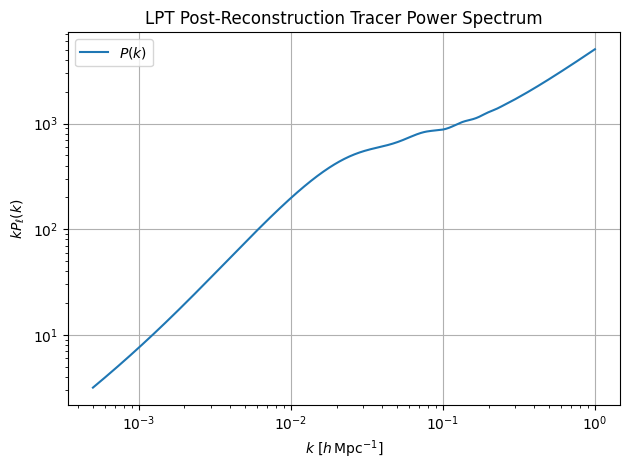

In [7]:
plt.loglog(forecast.k,forecast.k*Pk_mu0_lpt, label=fr"$P(k)$")
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$kP_{\ell}(k)$")
plt.legend()
plt.title("LPT Post-Reconstruction Tracer Power Spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()